# ML-10: Content Action Playbook

## SECTION 1 — Purpose and Validated Input

This playbook ranks content for human review based on our validated ML-09 model.

**Important Context on Validation:**
Our initial W05 model achieved 64.00% Precision@100 but was suffering from target leakage (using future traffic metrics to predict future traffic decay). In ML-09, we built a safe, defensible model grouped by client that achieved **51.00% Precision@100**. This safe model is what we use to generate this playbook. We do NOT rely on the inflated 64.00% result for operational decision making.

**Goal:** Provide SEO and Content teams with a prioritized queue of pages that the model predicts are decaying, enabling proactive content refreshes.


In [1]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

# Ensure output and figures dirs exist
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../figures', exist_ok=True)


## SECTION 2 — Data Load and Model Execution

We retrain the safe ML-09 model and use it to score the test set to simulate our production queue.


In [2]:
# Load data
df = pd.read_csv('../../data/raw/content_refresh_anonymized.csv')

# Target
df['is_declining'] = (df['trend_direction'] == 'down').astype(int)

# Safe Features Only (from ML-09)
features_num_safe = ['days_since_last_update', 'word_count', 'search_volume', 'competition', 'cpc']
features_cat = ['content_type', 'main_intent']

df_safe = df.copy()
df_safe[features_num_safe] = df_safe[features_num_safe].fillna(0)

# One-hot encode
df_encoded = pd.get_dummies(df_safe[features_cat], drop_first=True, dtype=int)
X_safe = pd.concat([df_safe[features_num_safe], df_encoded], axis=1)
y = df_safe['is_declining']
groups = df_safe['client_id']

# Grouped Split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_safe, y, groups))

X_train, X_test = X_safe.iloc[train_idx], X_safe.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Train
rf_safe = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_safe.fit(X_train, y_train)

# Predict
test_df = df.iloc[test_idx].copy()
test_df['ml_score_safe'] = rf_safe.predict_proba(X_test)[:, 1]

# Take Top 200 items as our action queue
queue_df = test_df.sort_values(by='ml_score_safe', ascending=False).head(200).copy()
print(f"Generated queue of {len(queue_df)} items.")


Generated queue of 200 items.


## SECTION 3 — Reason Codes

We generate operational reason codes based on the model's key features to guide human reviewers.
- **DECAY_SIGNAL**: Model predicts high decay probability.
- **HIGH_PRIORITY_REVIEW**: High decay probability + High Search Volume (>= 1000).
- **CONTENT_STALE**: High decay probability + Old Content (>= 365 days since update).


In [3]:
def assign_reason_code(row):
    reasons = []
    if row['search_volume'] >= 1000:
        reasons.append('HIGH_PRIORITY_REVIEW')
    if row['days_since_last_update'] >= 365:
        reasons.append('CONTENT_STALE')
    if not reasons:
        reasons.append('DECAY_SIGNAL')
    return ' | '.join(reasons)

def assign_priority(row):
    if row['search_volume'] >= 5000:
        return 'P1'
    elif row['search_volume'] >= 1000 or row['days_since_last_update'] >= 730:
        return 'P2'
    return 'P3'

queue_df['reason_code'] = queue_df.apply(assign_reason_code, axis=1)
queue_df['priority'] = queue_df.apply(assign_priority, axis=1)
queue_df['rank'] = range(1, len(queue_df) + 1)
queue_df['recommended_action'] = 'Human Review - Investigate Content Relevance/Decay'

# Select final columns for playbook
playbook_cols = ['rank', 'client_id', 'content_id', 'ml_score_safe', 'priority', 'reason_code', 'recommended_action', 'days_since_last_update', 'search_volume']
playbook_df = queue_df[playbook_cols]

display(playbook_df.head(10))


,rank,client_id,content_id,ml_score_safe,priority,reason_code,recommended_action,days_since_last_update,search_volume
26547,1,client_4e07408562,content_dbb4c75afccc,0.900951,P3,DECAY_SIGNAL,Human Review - Investigate Content Relevance/D...,104,10.0
12651,2,client_8527a891e2,content_2a228ce7aa1b,0.897627,P3,DECAY_SIGNAL,Human Review - Investigate Content Relevance/D...,92,0.0
29895,3,client_8527a891e2,content_901b40631379,0.896152,P3,DECAY_SIGNAL,Human Review - Investigate Content Relevance/D...,98,0.0
7922,4,client_8527a891e2,content_75bbe9161b5d,0.891794,P3,DECAY_SIGNAL,Human Review - Investigate Content Relevance/D...,102,0.0
28989,5,client_8527a891e2,content_5a2c8f6bafa5,0.891568,P3,DECAY_SIGNAL,Human Review - Investigate Content Relevance/D...,98,0.0
9535,6,client_8527a891e2,content_488f346b4086,0.891568,P3,DECAY_SIGNAL,Human Review - Investigate Content Relevance/D...,92,0.0
1600,7,client_8527a891e2,content_837c4ebfd762,0.891371,P3,DECAY_SIGNAL,Human Review - Investigate Content Relevance/D...,92,0.0
20491,8,client_8527a891e2,content_9e40f2d86a76,0.890640,P3,DECAY_SIGNAL,Human Review - Investigate Content Relevance/D...,104,0.0
19542,9,client_8527a891e2,content_72c8c4a76ef1,0.888986,P3,DECAY_SIGNAL,Human Review - Investigate Content Relevance/D...,98,0.0
5450,10,client_8527a891e2,content_da1c25c60d66,0.888986,P3,DECAY_SIGNAL,Human Review - Investigate Content Relevance/D...,92,0.0


## SECTION 4 — Intended Use and Limits

**INTENDED USE:**
- Prioritizing pages/content for human review by SEO and Content teams.
- Helping teams decide what to investigate first to combat content decay.
- Creating a ranked review queue, supporting recommendations in the research paper.

**LIMITS:**
- The model output is **not** a final decision.
- Ranking does not prove causality (e.g., updating the page may not guarantee traffic recovery).
- Predictions should not automatically trigger content changes.
- Validated performance (51% P@100) is based on a specific client-grouped validation setup and historical data. Results may change on new clients or shifted data.
- Human review remains strictly necessary.


## SECTION 5 — Human Review + No-Go List

The central principle of this playbook is:
**MODEL → RANKED REVIEW QUEUE → HUMAN DECISION → ACTION**

### Explicit No-Go List (Automated Actions FORBIDDEN)
- ❌ Automatically publishing or editing content based on model scores.
- ❌ Automatically deleting pages.
- ❌ Automatically changing important SEO metadata (title tags, meta descriptions).
- ❌ Automatically redirecting URLs or changing canonical URLs.
- ❌ Automatically making major site-wide structural or content changes.


## SECTION 6 — Monitoring / Retrain Triggers

To ensure the model remains safe and effective in operation, we define the following monitoring triggers:

- **Precision@100 Degradation:** Retrain or halt model if field-validated P@100 drops below 40% (base acceptable threshold below 51%).
- **Distribution / Data Drift:** Monitor `search_volume` and `days_since_last_update` inputs. Retrain if new client portfolios severely skew the distribution.
- **Repeated False Positives:** If content teams consistently reject recommendations for the same `reason_code` (e.g., flagging evergreen old content as decaying), the feature logic must be audited.


## SECTION 7 — Exports for the Paper
Exporting the ranked action queue to CSV and generating a priority distribution figure for the paper.


Exported w07_ranked_action_queue.csv


C:\Users\Admin\AppData\Local\Temp\ipykernel_18656\812147681.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=playbook_df, x='priority', order=['P1', 'P2', 'P3'], palette='Blues_r')


Exported w07_priority_distribution.png


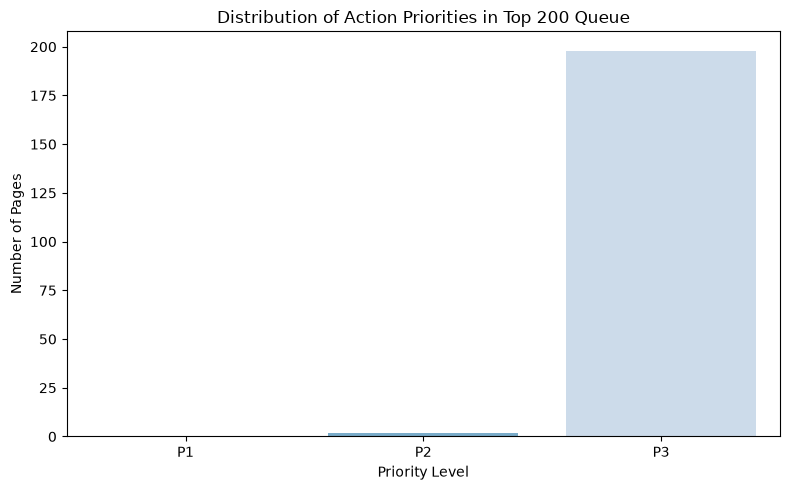

In [4]:
# Export Ranked Queue
playbook_df.to_csv('../outputs/w07_ranked_action_queue.csv', index=False)
print("Exported w07_ranked_action_queue.csv")

# Generate Priority Distribution Figure
plt.figure(figsize=(8, 5))
sns.countplot(data=playbook_df, x='priority', order=['P1', 'P2', 'P3'], palette='Blues_r')
plt.title('Distribution of Action Priorities in Top 200 Queue')
plt.xlabel('Priority Level')
plt.ylabel('Number of Pages')
plt.tight_layout()
plt.savefig('../figures/w07_priority_distribution.png', dpi=300)
print("Exported w07_priority_distribution.png")
plt.show()
